### NOTICE
#### Below code is just for ensuring the versions used by the SpaceDebrisRadar virtual enviornment.

In [1]:
import sys
import importlib

libs = ["pandas", "streamlit", "matplotlib", "seaborn", "sklearn", 'numpy', 'sklearn', 'scipy']

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print("-" * 70)

for lib in libs:
    try:
        module = importlib.import_module(lib)
        print(f"{lib} version: {module.__version__}")
        print(f"{lib} path: {module.__file__}")
    except ModuleNotFoundError:
        print(f"{lib} is NOT installed in this environment.")
    print("-" * 70)


Python executable: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\python.exe
Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
----------------------------------------------------------------------
pandas version: 2.3.3
pandas path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\pandas\__init__.py
----------------------------------------------------------------------
streamlit version: 1.48.0
streamlit path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\streamlit\__init__.py
----------------------------------------------------------------------
matplotlib version: 3.10.0
matplotlib path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\matplotlib\__init__.py
----------------------------------------------------------------------
seaborn version: 0.13.2
seaborn path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\seaborn\__init__.py
---------------------------

In [2]:
# IMPORT HERE!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [3]:
#df = pd.read_csv('https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv', low_memory=False)
df = pd.read_csv('../data/01_raw/gp.csv')

### 📑 Useful Columns for SpaceDebrisRadar.AI

| Column Name     | Description                           | Usage in Project (ML/Logic) |
|-----------------|---------------------------------------|------------------------------|
| NORAD_CAT_ID    | Unique satellite identifier           | Tracking & referencing       |
| OBJECT_NAME     | Satellite/system name                 | System-based queries (e.g., Starlink) |
| MEAN_MOTION     | Revolutions per day (orbit speed)     | Clustering (KMeans), anomaly trends |
| INCLINATION     | Orbital tilt in degrees               | Clustering (shell grouping)  |
| ECCENTRICITY    | Orbit shape (circular vs. elliptical) | Orbit stability, anomaly detection |
| BSTAR           | Drag coefficient proxy                | Anomaly detection (decay risk) |
| EPOCH           | Timestamp of orbital elements         | Time-series, forecasting     |

----
### 🔎 About OBJECT_ID (A, B, C parts)

- `OBJECT_ID` format → `YYYY-NNNP`  
  - `YYYY` → Launch year  
  - `NNN` → Launch number in that year  
  - `P` → Piece (A, B, C, …)

- `A` → Primary payload (main satellite)  
- `B, C, …` → Secondary payloads, rocket bodies, or debris  
- Each part is a **separate object** in orbit (they do not join back).  
- Useful for anomaly detection → older `B/C` objects are often unstable or decaying.


In [4]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,U,900,999,4466,0.001228,1.211000e-05,0.0
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,U,902,999,82995,0.000097,7.400000e-07,0.0
2,LCS 1,1965-034C,2025-12-04T11:40:34.858848,9.893095,0.001344,32.1426,279.3197,153.3358,206.7832,0,U,1361,999,19060,0.001319,1.800000e-07,0.0
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,U,1512,999,93412,0.000160,8.900000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,U,1520,999,93673,0.000319,1.750000e-06,0.0


In [5]:
df.shape

(13551, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13551 entries, 0 to 13550
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          13551 non-null  object 
 1   OBJECT_ID            13551 non-null  object 
 2   EPOCH                13551 non-null  object 
 3   MEAN_MOTION          13551 non-null  float64
 4   ECCENTRICITY         13551 non-null  float64
 5   INCLINATION          13551 non-null  float64
 6   RA_OF_ASC_NODE       13551 non-null  float64
 7   ARG_OF_PERICENTER    13551 non-null  float64
 8   MEAN_ANOMALY         13551 non-null  float64
 9   EPHEMERIS_TYPE       13551 non-null  int64  
 10  CLASSIFICATION_TYPE  13551 non-null  object 
 11  NORAD_CAT_ID         13551 non-null  int64  
 12  ELEMENT_SET_NO       13551 non-null  int64  
 13  REV_AT_EPOCH         13551 non-null  int64  
 14  BSTAR                13551 non-null  float64
 15  MEAN_MOTION_DOT      13551 non-null 

In [7]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
count,13551.000000,13551.000000,13551.000000,13551.000000,13551.000000,13551.000000,13551.0,13551.000000,13551.0,13551.000000,13551.000000,13551.000000,13551.000000
mean,14.210420,0.002831,59.251137,173.236830,165.578565,195.728066,0.0,56162.366615,999.0,12875.865914,0.000286,0.000112,0.000022
std,3.279599,0.039731,23.671874,107.737364,94.704296,95.428646,0.0,8485.149850,0.0,13097.591193,0.005695,0.003403,0.001720
min,0.284001,0.000004,0.000700,0.009100,0.132100,0.206700,0.0,900.000000,999.0,2.000000,-0.197780,-0.094059,-0.000001
25%,14.983581,0.000125,43.003800,73.689800,87.649250,93.003000,0.0,52097.000000,999.0,3811.000000,0.000052,0.000002,0.000000
50%,15.088472,0.000155,53.160100,169.819900,112.474500,249.407500,0.0,58054.000000,999.0,9899.000000,0.000197,0.000023,0.000000
75%,15.302014,0.000301,80.465600,267.552900,267.339650,272.873400,0.0,62880.500000,999.0,18169.000000,0.001139,0.000282,0.000000
max,16.465343,0.875235,147.800800,359.988100,359.889800,359.972100,0.0,66877.000000,999.0,99911.000000,0.105120,0.170084,0.158408


In [8]:
df['OBJECT_NAME']

0          CALSPHERE 1
1          CALSPHERE 2
2                LCS 1
3            TEMPSAT 1
4         CALSPHERE 4A
             ...      
13546     SNUGLITE-III
13547        2025-274N
13548      SOYUZ-MS 28
13549        KOMPSAT-7
13550    DUMMY PAYLOAD
Name: OBJECT_NAME, Length: 13551, dtype: object

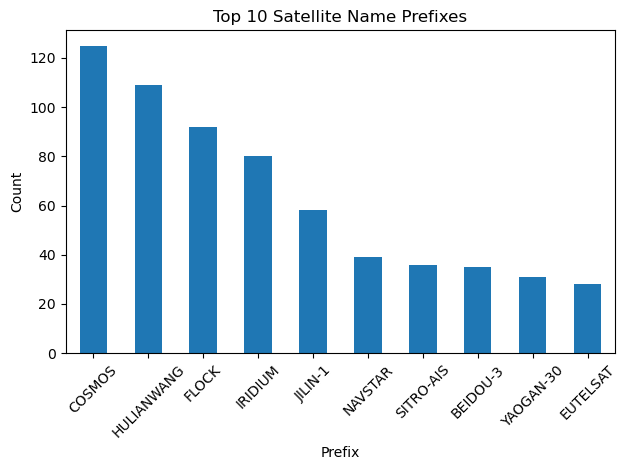

In [9]:
df['OBJECT_NAME'].str.split().str[0].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Satellite Name Prefixes')
plt.xlabel('Prefix')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()



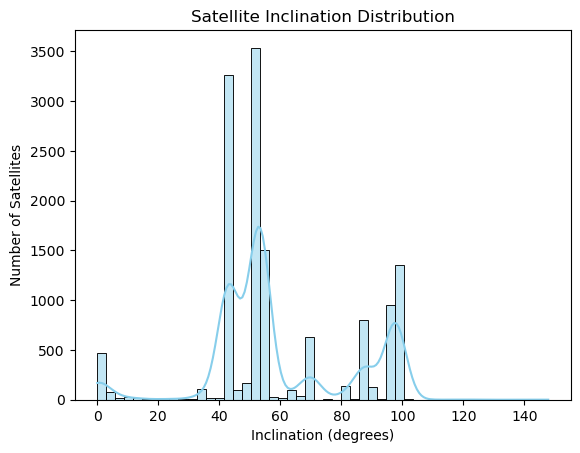

In [10]:
sns.histplot(data=df, x = 'INCLINATION', bins=50, color='skyblue', kde = True)

plt.title('Satellite Inclination Distribution')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Number of Satellites')
plt.show()


(0.0, 0.05)

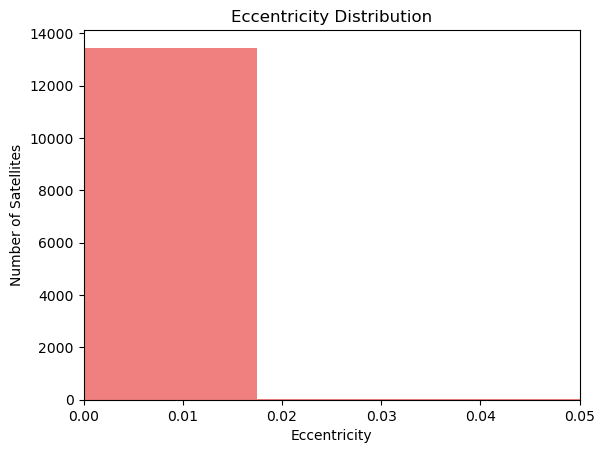

In [11]:
df['ECCENTRICITY'].plot(kind='hist', bins=50, color='lightcoral')
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity')
plt.ylabel('Number of Satellites')

plt.xlim(0, 0.05)

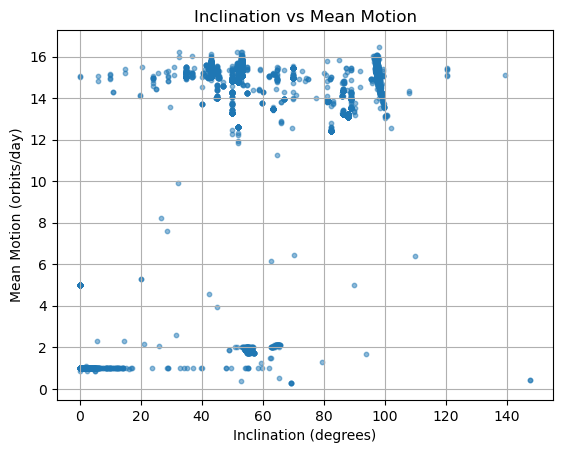

In [12]:
plt.scatter(df['INCLINATION'], df['MEAN_MOTION'], alpha=0.5, s=10)
plt.title('Inclination vs Mean Motion')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Mean Motion (orbits/day)')
plt.grid(True)
plt.show()


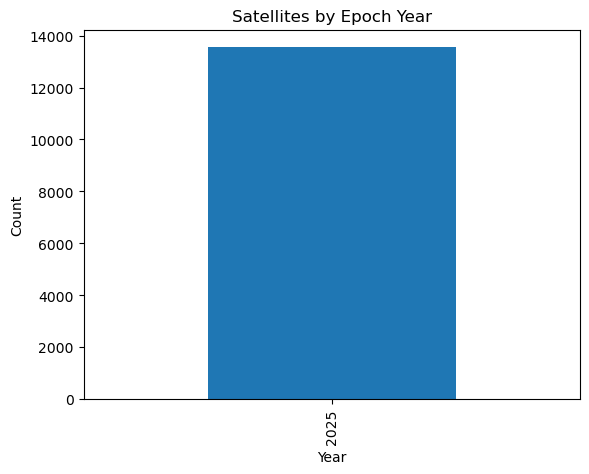

In [13]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'], errors='coerce')
df['EPOCH'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Satellites by Epoch Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


In [14]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
13546,SNUGLITE-III,2025-274M,2025-12-04 13:27:54.573120,14.930341,0.001368,97.7386,265.9163,312.7426,47.2642,0,U,66661,999,118,0.000525,0.000054,0.000000
13547,2025-274N,2025-274N,2025-12-04 08:37:53.431680,14.930896,0.001410,97.7387,265.7189,312.6803,47.3228,0,U,66662,999,115,0.000388,0.000040,0.000000
13548,SOYUZ-MS 28,2025-275A,2025-12-04 13:02:29.700384,15.493060,0.000360,51.6299,183.0583,202.7086,157.3744,0,U,66664,999,117,0.000293,0.000159,0.000000
13549,KOMPSAT-7,2025-279A,2025-12-01 20:35:16.060992,14.983106,0.000975,97.6394,281.9587,255.3935,104.6207,0,U,66820,999,2,0.000084,0.000009,0.000000
13550,DUMMY PAYLOAD,2025-282A,2025-12-04 16:11:05.422848,14.390092,0.086454,56.9559,88.0896,206.2177,149.2529,0,U,66877,999,22,0.000252,0.011237,0.000007


In [15]:
df[df['OBJECT_NAME'].str.contains('STARLINK')]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
1358,STARLINK-1008,2019-074B,2025-12-04 11:55:52.953888,15.064112,0.000181,53.0558,253.9524,77.1178,283.0013,0,U,44714,999,33440,0.000495,0.000071,0.000000
1359,STARLINK-1011,2019-074E,2025-12-04 06:04:59.965248,16.240964,0.000547,53.0358,214.9690,226.0644,133.9945,0,U,44717,999,33492,0.000962,0.026655,0.000012
1360,STARLINK-1012,2019-074F,2025-12-04 11:24:02.165184,15.064110,0.000172,53.0534,254.0472,81.0262,279.0921,0,U,44718,999,33439,0.000749,0.000109,0.000000
1361,STARLINK-1017,2019-074L,2025-12-04 11:49:09.912576,15.174604,0.000638,53.0496,248.2214,68.5914,291.5760,0,U,44723,999,33448,0.001644,0.000332,0.000000
1362,STARLINK-1019,2019-074M,2025-12-04 17:07:34.411872,15.554580,0.000468,53.0531,244.2679,110.6678,249.4834,0,U,44724,999,33455,0.001963,0.001382,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13526,STARLINK-35921,2025-271Z,2025-12-04 07:07:23.950272,15.813189,0.000496,53.1562,228.5854,9.2257,350.8856,0,U,66640,999,288,0.001570,0.003280,0.000000
13527,STARLINK-35923,2025-271AA,2025-12-04 04:02:26.143296,15.817182,0.000119,53.1554,229.2043,158.0841,202.0234,0,U,66641,999,286,-0.004399,-0.008225,0.000000
13528,STARLINK-35926,2025-271AB,2025-12-04 16:11:02.031648,15.816535,0.000827,53.1555,226.6722,225.4105,134.6244,0,U,66642,999,290,0.002900,0.006391,0.000000
13529,STARLINK-35918,2025-271AC,2025-12-04 16:12:06.771168,15.817830,0.000746,53.1555,226.6780,210.1435,149.9160,0,U,66643,999,294,0.004293,0.009915,0.000000


Text(0.5, 0, 'Mean Motion')

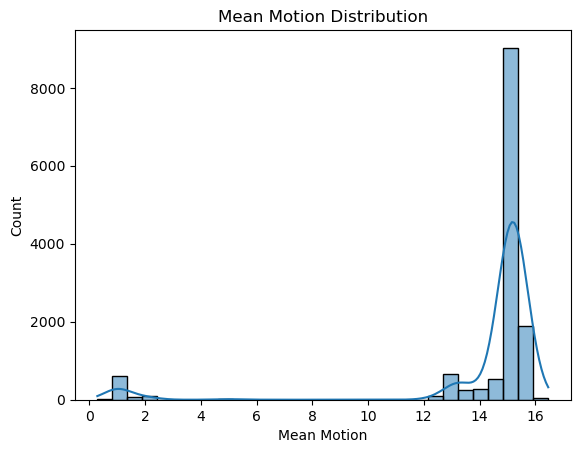

In [16]:
sns.histplot(data=df, x = 'MEAN_MOTION', bins = 30, kde=True)

plt.title('Mean Motion Distribution')
plt.xlabel('Mean Motion')


In [17]:
df['BSTAR'].value_counts()

BSTAR
 0.000000    790
 0.000293      8
 0.000477      5
 0.000101      3
 0.000109      3
            ... 
 0.000004      1
-0.002239      1
 0.000550      1
 0.000024      1
 0.000375      1
Name: count, Length: 12290, dtype: int64

(-0.2, 0.2)

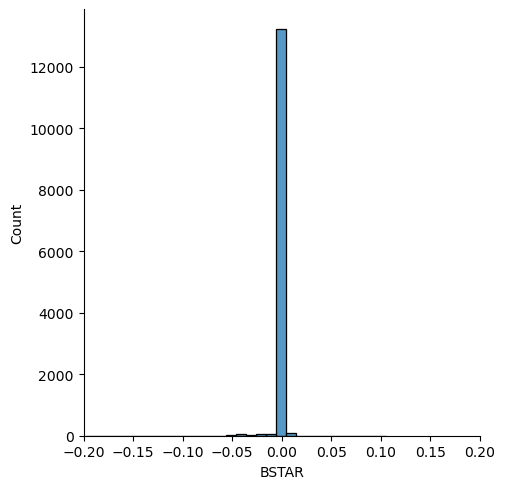

In [18]:
sns.displot(data=df, x = 'BSTAR', bins = 30)

plt.xlim(-0.2, 0.2)
#plt.ylim(-0.1, 2)

Text(0.5, 0, 'Revolutions')

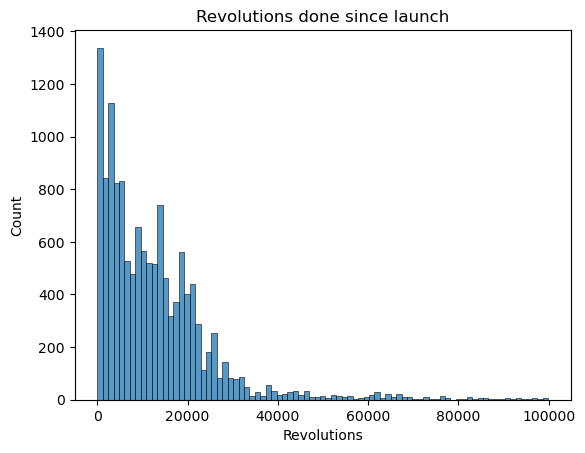

In [19]:
sns.histplot(data=df, x = 'REV_AT_EPOCH')

plt.title('Revolutions done since launch')
plt.xlabel('Revolutions')

In [20]:
# Compare total orbits done and the launch year distribution
launch_years = df['OBJECT_ID'].str.strip().str.split('-').str[0]

In [21]:
launch_years

0        1964
1        1964
2        1965
3        1965
4        1965
         ... 
13546    2025
13547    2025
13548    2025
13549    2025
13550    2025
Name: OBJECT_ID, Length: 13551, dtype: object

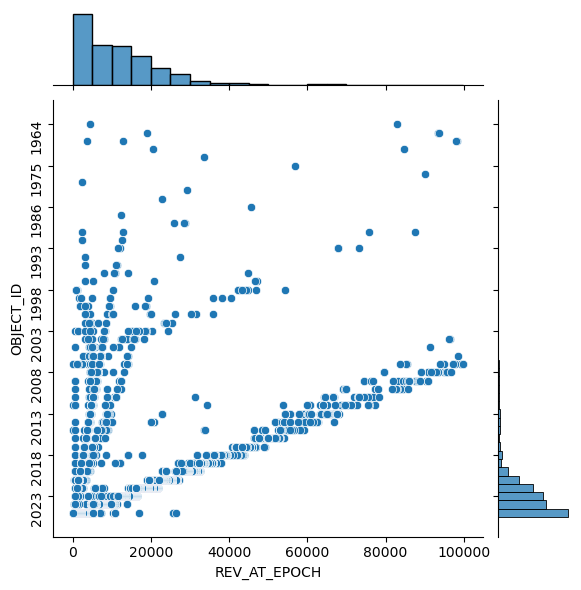

In [22]:
import matplotlib.ticker as ticker
g = sns.jointplot(data=df, x='REV_AT_EPOCH', y=launch_years, kind='scatter', marginal_kws=dict(bins=20, orientation="vertical"))

# Set a major tick for every 5 years on the y-axis
g.ax_joint.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.ax_joint.tick_params(axis='y', rotation=90)

plt.show()